# Week 2: Data Cleaning and Preprocessing

## Cardiovascular Disease Prediction using Machine Learning

### Objectives
- Handle missing values
- Check duplicate records
- Detect and handle outliers
- Encode categorical variables
- Normalize/Scale numerical features
- Prepare data for Machine Learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("cardio_train (1).csv", sep=";")

In [3]:
df.head()#display first 5

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
print("Dataset Shape:", df.shape) #dataset dimensions

Dataset Shape: (70000, 13)


### Observation

The dataset has been loaded successfully.

It contains patient health records that will be cleaned and preprocessed before training machine learning models.

## 1. Checking Missing Values

Missing values can affect the performance of machine learning models. Therefore, it is important to identify and handle them before training the model.

In [5]:
df.isnull().sum() #would get the sum of missing values

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### Observation

No missing values were found in the dataset.

Therefore, no missing value treatment is required.

## 2. Checking Duplicate Records

Duplicate records can negatively impact the performance of machine learning models by introducing bias. Therefore, it is important to identify and remove duplicate entries before training the model.

In [6]:
duplicate_count = df.duplicated().sum() #to check for duplicate once
print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


### Observation

No duplicate records were found in the dataset.

Therefore, no duplicate records were removed, and the dataset is ready for the next preprocessing step.

## 3. Fix Data Types

Machine learning algorithms require data to be in the correct format. Therefore, the data types of all columns are checked to ensure they are appropriate for analysis and model training.

In [7]:
df.info()    #to get the datatype of all columns,not null values,total rows and cols,and their cols name 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### Observation

All columns have appropriate data types. No data type conversion was required before preprocessing.

## 4. Detecting and Handling Outliers

Outliers are extreme values that differ significantly from the rest of the data. They can negatively affect the performance of machine learning models.

In this step, boxplots are used to identify outliers, and the Interquartile Range (IQR) method is applied to handle them.

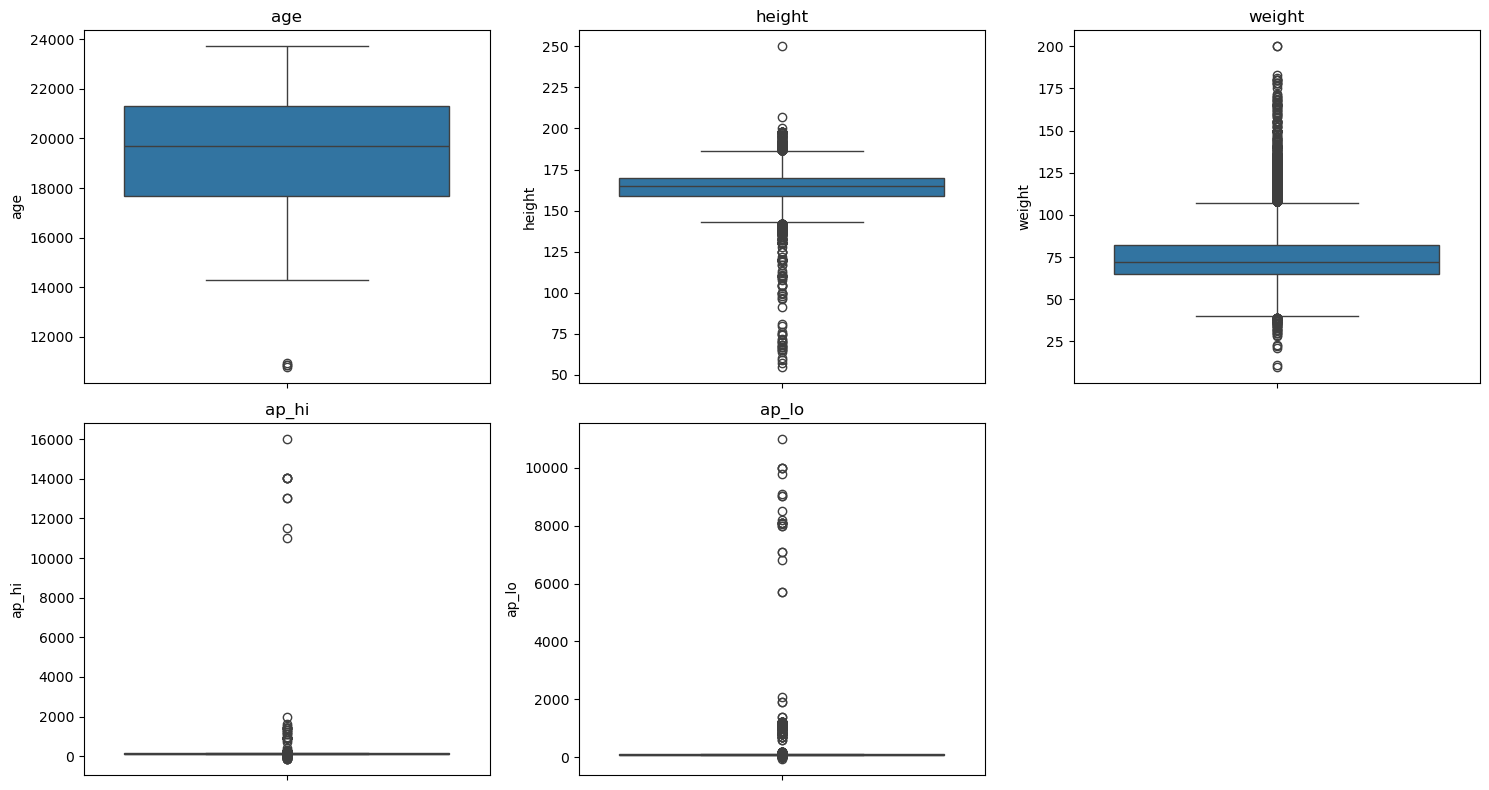

In [8]:
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Observation

The boxplots were used to detect outliers in the numerical features.

- **Age:** Very few outliers are present, indicating that most patients belong to a similar age range.
- **Height:** Some outliers are visible at both the lower and upper ends, representing unusually short or tall individuals.
- **Weight:** Several outliers are observed, indicating patients with unusually low or high body weight.
- **Systolic Blood Pressure (ap_hi):** A large number of extreme outliers are present. Some values are unrealistically high, which may be due to data entry errors.
- **Diastolic Blood Pressure (ap_lo):** Many extreme outliers are also observed, suggesting the presence of abnormal or incorrect blood pressure values.

Since outliers can negatively affect machine learning models, they will be handled using the Interquartile Range (IQR) method.

## 5. Handling Outliers Using IQR Method

The Interquartile Range (IQR) method is used to identify and remove extreme outliers from the blood pressure columns (ap_hi and ap_lo). This improves the quality of the dataset while preserving most valid patient records.

In [9]:
Q1 = df['ap_hi'].quantile(0.25)
Q3 = df['ap_hi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: 90.0
Upper Limit: 170.0


In [10]:
# Remove outliers from ap_hi
df = df[(df['ap_hi'] >= lower) & (df['ap_hi'] <= upper)]

print("Dataset Shape after removing ap_hi outliers:", df.shape)

Dataset Shape after removing ap_hi outliers: (68565, 13)


In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['ap_hi'])
plt.title("Boxplot of ap_hi after Outlier Removal")
plt.show()

### 

Observation

The IQR method was applied to the `ap_hi` (Systolic Blood Pressure) column.

- Lower Limit = **90**
- Upper Limit = **170**

Rows with values outside this range were removed as outliers. As a result, the dataset size changed from **70,000** records to **68,565** records.

The updated boxplot confirms that the extreme outliers have been successfully removed, resulting in a cleaner and more reliable dataset for model training.

In [11]:
Q1 = df['ap_lo'].quantile(0.25)
Q3 = df['ap_lo'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: 65.0
Upper Limit: 105.0


In [12]:
# Remove outliers from ap_lo
df = df[(df['ap_lo'] >= lower) & (df['ap_lo'] <= upper)]

print("Dataset Shape after removing ap_lo outliers:", df.shape)

Dataset Shape after removing ap_lo outliers: (64502, 13)


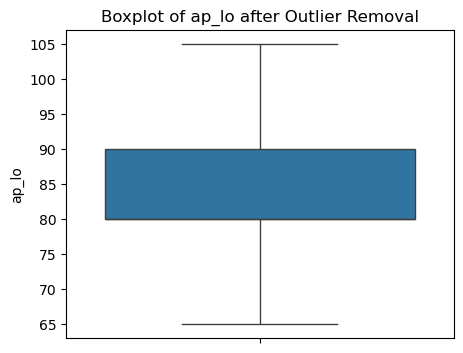

In [13]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['ap_lo'])
plt.title("Boxplot of ap_lo after Outlier Removal")
plt.show()

### Observation

The IQR method was applied to the `ap_lo` (Diastolic Blood Pressure) column.

- Lower Limit = **65**
- Upper Limit = **105**

Values outside this range were removed as outliers. After removing the outliers, the dataset size was reduced to **64,502** records.

The updated boxplot confirms that the extreme values have been successfully removed, resulting in a cleaner dataset suitable for machine learning.

In [14]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0


## 6. Feature Scaling

Machine learning algorithms perform better when numerical features are on a similar scale.

StandardScaler is used to standardize the numerical features by transforming them to have a mean of 0 and a standard deviation of 1.

In [15]:
# Separate features and target variable
X = df.drop('cardio', axis=1)   #x-->features    y-->target variable
y = df['cardio']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (64502, 12)
Target Shape: (64502,)


In [16]:
scaler = StandardScaler()     #z=(x−mean)/standard deviation    Mean ≈ 0    Standard Deviation ≈ 1
X_scaled = scaler.fit_transform(X)    #fit()-->Calculates the mean and standard deviation   , transform()-->Uses those values to scale
print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

### Observation

The numerical features were standardized using StandardScaler.

After scaling, all features have a similar range with a mean close to 0 and a standard deviation close to 1.

This helps improve the performance of many machine learning algorithms by preventing features with larger values from dominating the model.

## 7. Encoding Categorical Variables

Encoding is the process of converting categorical data into numerical form so that machine learning algorithms can understand it.

In this dataset, all categorical columns are already represented using numeric values. Therefore, no additional encoding is required.

In [17]:
print("Encoding is not required because categorical columns are already represented using numeric values.")    # categorial--> numerical data

Encoding is not required because categorical columns are already represented using numeric values.


## 8. Feature Scaling

Feature scaling is performed to bring numerical features into a common range between 0 and 1.

MinMaxScaler is used because it transforms all numerical features to the same scale, which helps improve the performance of machine learning algorithms.

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()        #featurescaling--> to bring numerical data to common range
cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']   #-->list of numerical columns
df[cols] = scaler.fit_transform(df[cols])    #fit--> min max of each col  , transform()-->Converts every value to a number between 0 and 1
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.586121,2,0.579487,0.269841,0.250,0.375,1,1,0,0,1,0
1,1,0.728878,1,0.517949,0.391534,0.625,0.625,3,1,0,0,1,1
2,2,0.622219,1,0.564103,0.280423,0.500,0.125,3,1,0,0,0,1
3,3,0.526218,2,0.584615,0.375661,0.750,0.875,1,1,0,0,1,1
5,8,0.860044,1,0.492308,0.296296,0.375,0.375,2,2,0,0,0,0


### Observation

The selected numerical features were successfully scaled using MinMaxScaler.

After scaling, all values lie between **0 and 1**, ensuring that no single feature dominates the machine learning model due to its larger numerical range.

## 9. Save the Preprocessed Dataset

After completing data preprocessing, the cleaned dataset is saved as a new CSV file. This dataset will be used in the next phase for training and evaluating machine learning models.

In [19]:
df.to_csv("cardio_train_cleaned.csv", index=False)
print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


# Week 2 Conclusion

In this week, the cardiovascular dataset was successfully preprocessed.

The preprocessing steps included:
- Checking missing values
- Checking duplicate records
- Verifying data types
- Detecting and handling outliers using the IQR method
- Verifying categorical encoding
- Scaling numerical features using MinMaxScaler
- Saving the cleaned dataset

The dataset is now clean and ready for machine learning model development in Week 3.